In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
x,y=load_iris(as_frame=True,return_X_y=True)
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
lr=LogisticRegression()
lr.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [ ]:
lr.fit(train_x,train_y)

LogisticRegression()

In [ ]:
lr.coef_

array([[-0.39345607,  0.96251768, -2.37512436, -0.99874594],
       [ 0.50843279, -0.25482714, -0.21301129, -0.77574766],
       [-0.11497673, -0.70769055,  2.58813565,  1.7744936 ]])

In [ ]:
lr.score(train_x,train_y)

0.975

In [ ]:
lr.score(test_x,test_y)

1.0

In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(train_x,train_y)

KNeighborsClassifier()

In [ ]:
knn.score(train_x,train_y)

0.9666666666666667

In [ ]:
knn.score(test_x,test_y)

1.0

In [ ]:
tree=DecisionTreeClassifier()
tree.fit(train_x,train_y)

DecisionTreeClassifier()

In [ ]:
tree.score(train_x,train_y)

1.0

In [ ]:
tree.score(test_x,test_y)

1.0

In [ ]:
sv=SVC(kernel='rbf')
sv.fit(train_x,train_y)

SVC()

In [ ]:
sv.fit(train_x,train_y)

SVC()

In [ ]:
sv.score(train_x,train_y)

0.975

In [ ]:
sv.score(test_x,test_y)

1.0

In [ ]:
sgd=SGDClassifier(loss='log_loss') # default is hinge loss
sgd.get_params()

{'alpha': 0.0001,
 'average': False,
 'class_weight': None,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.0,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'optimal',
 'loss': 'log_loss',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'n_jobs': None,
 'penalty': 'l2',
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
sgd.fit(train_x,train_y)
sgd.score(train_x,train_y)

0.7666666666666667

In [ ]:
sgd.score(test_x,test_y)

0.8

# Batch building

In [ ]:
x.shape

(150, 4)

In [ ]:
batch_size=50
sgd1=SGDClassifier(random_state=42)
for i in range(0,train_x.shape[0],batch_size):
  x_train_batch=train_x[i:i+batch_size]
  y_train_batch=train_y[i:i+batch_size]
  sgd1.partial_fit(x_train_batch,y_train_batch,classes=np.unique(train_y))

sgd1.score(train_x,train_y)

0.6583333333333333

In [ ]:
sgd1.score(test_x,test_y)

0.7

#Pruning

Pre pruning
- for example max leaf nodes,max depth etc which we define before running model

Post Pruning
- CCP(cost complexity pruning) basically in simple words after running the algo and getting done with all the stuff this algo will remove nodes 1 by 1 (with the help of alpha) because of which impurity increases but total number of nodes decreases(do check explanation on google for detailed one)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
tree1=DecisionTreeClassifier(random_state=42)
path=tree1.cost_complexity_pruning_path(train_x,train_y)
ccp_alphas,impurities=path.ccp_alphas,path.impurities
# https://chatgpt.com/share/695f8ec7-bdc8-800c-a1ba-7b8459a66127  for explanation of ccp aplha and impurities co relation

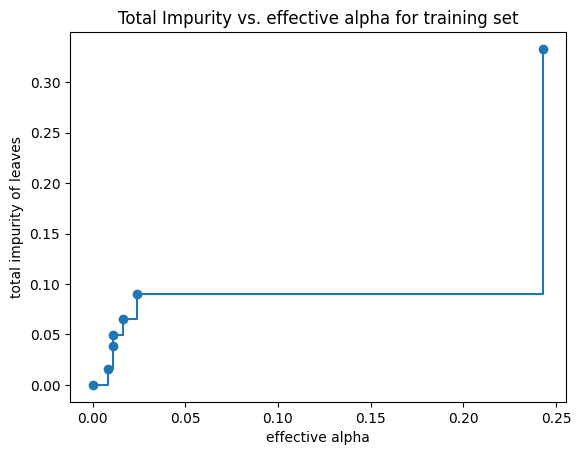

In [ ]:
plt.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
plt.xlabel("effective alpha")
plt.ylabel("total impurity of leaves")
plt.title("Total Impurity vs. effective alpha for training set")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier

In [ ]:
tree2=DecisionTreeClassifier(random_state=25)
path1=tree2.cost_complexity_pruning_path(train_x,train_y)
ccp_alphas1,impurities1=path1.ccp_alphas,path1.impurities

In [ ]:
sco_train=[]
sco_test=[]
for i in ccp_alphas1:
  tree_batch=DecisionTreeClassifier(random_state=25,ccp_alpha=i)
  tree_batch.fit(train_x,train_y)
  sco_train.append(tree_batch.score(train_x,train_y))
  sco_test.append(tree_batch.score(test_x,test_y))

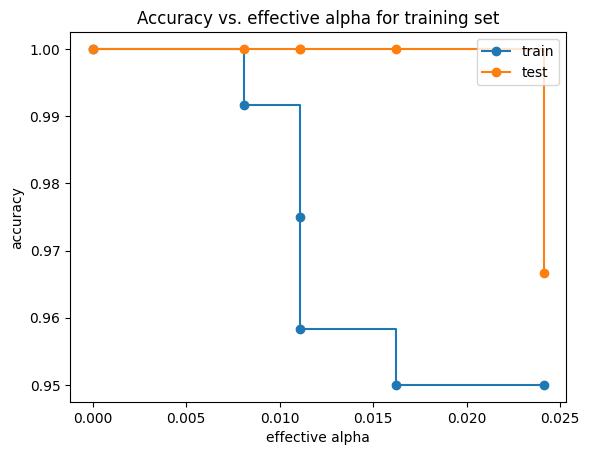

In [ ]:
plt.plot(ccp_alphas1[:-2], sco_train[:-2],label="train", marker='o', drawstyle="steps-post")
plt.plot(ccp_alphas1[:-2], sco_test[:-2],label='test' ,marker='o', drawstyle="steps-post")
plt.xlabel("effective alpha")
plt.ylabel("accuracy")
plt.title("Accuracy vs. effective alpha for training set")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
gs=GridSearchCV(RandomForestClassifier(),param_grid={'n_estimators':[100,200,300],'max_depth':[10,15,20,25],'min_samples_leaf':[1,2,3,4,5]},cv=5,n_jobs=2,verbose=True)
gs.fit(train_x,train_y)
# 3*4*5

Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=2,
             param_grid={'max_depth': [10, 15, 20, 25],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'n_estimators': [100, 200, 300]},
             verbose=True)

In [ ]:
gs.best_score_

np.float64(0.9666666666666666)

In [ ]:
gs.best_estimator_

RandomForestClassifier(max_depth=10, min_samples_leaf=5)

In [ ]:
pd.DataFrame(gs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.232498,0.006310,0.014089,0.000685,10,1,100,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.958333,1.000000,0.875000,1.000000,0.958333,0.958333,0.045644,2
1,0.466794,0.015546,0.025906,0.000966,10,1,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.958333,1.000000,0.833333,1.000000,0.958333,0.950000,0.061237,12
2,0.689149,0.015715,0.040317,0.006345,10,1,300,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.958333,0.958333,0.791667,1.000000,0.958333,0.933333,0.072648,56
3,0.257559,0.032586,0.017235,0.003874,10,2,100,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",0.958333,0.958333,0.833333,1.000000,0.958333,0.941667,0.056519,42
4,0.778404,0.062018,0.047007,0.014243,10,2,200,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",0.958333,1.000000,0.791667,1.000000,0.958333,0.941667,0.077280,42
5,0.914024,0.157437,0.045556,0.011779,10,2,300,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",0.958333,1.000000,0.833333,1.000000,0.958333,0.950000,0.061237,12
6,0.236624,0.011178,0.015365,0.001368,10,3,100,"{'max_depth': 10, 'min_samples_leaf': 3, 'n_es...",1.000000,1.000000,0.791667,1.000000,0.958333,0.950000,0.080795,12
7,0.463606,0.011068,0.025110,0.000193,10,3,200,"{'max_depth': 10, 'min_samples_leaf': 3, 'n_es...",1.000000,1.000000,0.833333,1.000000,0.958333,0.958333,0.064550,2
8,0.691080,0.010087,0.042986,0.012448,10,3,300,"{'max_depth': 10, 'min_samples_leaf': 3, 'n_es...",0.958333,1.000000,0.875000,1.000000,0.958333,0.958333,0.045644,2
9,0.234041,0.008983,0.014608,0.000638,10,4,100,"{'max_depth': 10, 'min_samples_leaf': 4, 'n_es...",0.958333,1.000000,0.833333,1.000000,0.958333,0.950000,0.061237,12


In [ ]:
gs.best_estimator_.score(test_x,test_y)

1.0

In [ ]:
rfc=RandomForestClassifier(n_estimators=100)
rfc.fit(train_x,train_y)
rfc.score(train_x,train_y)

1.0

In [ ]:
rfc.score(test_x,test_y)

1.0

#Bootstrap using bagging classifier
(basically sampling with replacement)


In [ ]:
from sklearn.ensemble import BaggingClassifier

In [ ]:
bg=BaggingClassifier(LogisticRegression(),bootstrap=True,n_estimators=10)
bg.fit(train_x,train_y)
bg.score(train_x,train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.9666666666666667

In [ ]:
bg.score(test_x,test_y)

1.0

#Boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier

In [ ]:
adb=AdaBoostClassifier() #decision trees are serially trained means
adb.get_params()

{'algorithm': 'deprecated',
 'estimator': None,
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': None}

In [ ]:
adb.fit(train_x,train_y)
adb.score(train_x,train_y)

1.0

In [ ]:
gdc=GradientBoostingClassifier() #decision trees are serially trained means
gdc.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
gdc.fit(train_x,train_y)
gdc.score(train_x,train_y)

1.0

In [ ]:
gdc.score(test_x,test_y)

1.0

-Serial training of decision trees:
Trees are trained one after another.
Each new tree depends on the errors of previous trees.
Common in boosting algorithms.

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
X,Y=load_digits(as_frame=True,return_X_y=True)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,shuffle=True,random_state=28)

In [ ]:
x_train #( 64 columns means 8*8 matrix)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
112,0.0,0.0,3.0,11.0,16.0,13.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,3.0,15.0,1.0,0.0,0.0,0.0
444,0.0,0.0,0.0,11.0,12.0,1.0,0.0,0.0,0.0,0.0,...,9.0,0.0,0.0,0.0,1.0,10.0,14.0,10.0,2.0,0.0
1473,0.0,0.0,0.0,13.0,1.0,0.0,0.0,0.0,0.0,0.0,...,12.0,0.0,0.0,0.0,1.0,9.0,16.0,14.0,2.0,0.0
356,0.0,0.0,2.0,15.0,12.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,16.0,5.0,0.0,0.0,0.0
1738,0.0,0.0,7.0,12.0,16.0,9.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,10.0,11.0,4.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,0.0,0.0,10.0,13.0,14.0,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,11.0,11.0,1.0,0.0,0.0,0.0
1056,0.0,0.0,5.0,12.0,16.0,12.0,4.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,3.0,12.0,0.0,0.0,0.0,0.0
1302,0.0,5.0,16.0,16.0,16.0,16.0,10.0,0.0,0.0,4.0,...,0.0,0.0,0.0,5.0,16.0,16.0,12.0,1.0,0.0,0.0
1541,0.0,0.0,5.0,12.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,7.0,15.0,12.0,2.0,0.0,0.0


In [ ]:
mat=np.reshape(x_train.iloc[100].values,(8,8))
mat

array([[ 0.,  0.,  0., 12.,  8.,  0.,  0.,  0.],
       [ 0.,  0.,  6., 16.,  3., 12.,  4.,  0.],
       [ 0.,  1., 16.,  5.,  8., 14.,  0.,  0.],
       [ 0.,  9., 15.,  0., 13., 10.,  2.,  0.],
       [ 0., 10., 15., 12., 16., 16.,  9.,  0.],
       [ 0.,  6., 16., 16., 15.,  9.,  1.,  0.],
       [ 0.,  0.,  0., 14.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 15.,  0.,  0.,  0.,  0.]])

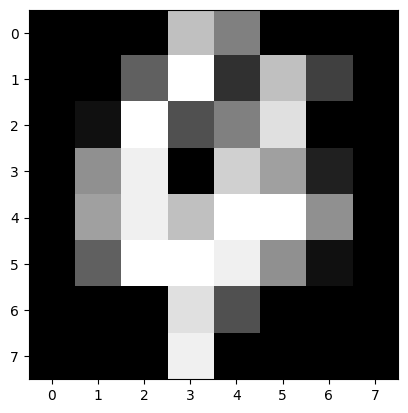

In [ ]:
import matplotlib.pyplot as pl
pl.imshow(mat , cmap='gray' ,interpolation='nearest')
pl.show()

In [ ]:
from sklearn.ensemble import VotingClassifier

In [ ]:
vc=VotingClassifier(estimators=[('lr1',LogisticRegression()),('dt',DecisionTreeClassifier()),('kn',KNeighborsClassifier())],voting='hard')
vc.fit(x_train,y_train)
vc.score(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1.0

In [ ]:
vc.score(x_test,y_test)

0.9638888888888889

In [ ]:
vc1=VotingClassifier(estimators=[('lr1',LogisticRegression()),('dt',DecisionTreeClassifier()),('kn',KNeighborsClassifier())],voting='soft')
vc1.fit(x_train,y_train)
vc1.score(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1.0

In [ ]:
vc1.score(x_test,y_test)

0.9694444444444444

lr=[0.7,0.3] ,0(hard)

dt=[0.4,0.6] ,1(hard)

kn=[0.6,0.4] ,0(hard)

soft=[1.7,1.3] ans 0

hard= ans 0 cuz of majority

In [ ]:
from sklearn.neural_network import MLPClassifier # neural network

mlpc=MLPClassifier(hidden_layer_sizes=(3,3,5,6),random_state=25,max_iter=300)
mlpc.fit(x_train,y_train)
mlpc.score(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


0.7940153096729298

In [ ]:
mlpc.predict_proba([x_train.iloc[0]])
# predict_proba() outputs the probability distribution over classes for a given input.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


array([[7.05712622e-17, 2.63518897e-02, 2.21547249e-03, 2.73112709e-03,
        1.36191850e-15, 3.12621274e-02, 5.78595228e-05, 9.35608218e-01,
        1.77330532e-03, 1.96845652e-16]])

In [ ]:
mlpc.predict([x_train.iloc[0]]) # basically probability of it being 7 is higher then all

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


array([7])

In [ ]:
mlpc.score(x_test,y_test)

0.7111111111111111

In [ ]:
y_test.unique()

array([8, 9, 5, 0, 7, 2, 6, 3, 4, 1])